In [9]:
from py_files.setup import *
setup_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Gini vs intangible capital

**Motivational figure:** Juxtaposes the Danish Gini coefficient (IFOR41, Statistics Denmark) against the intangible investment share of GDP. No causal claim is made — the co-movement provides empirical context for the distributional question the model addresses.

*`1. data`*

Gini from `IFOR41.csv` (comma-decimal). Intangible share from the `direct_NX` timeseries, defined as $(I^{\text{IPP}} + I^{\text{org}}) / \text{GDP}$.

In [10]:
# 1. Gini, fix comma to dot
gini = pd.read_csv('0_raw_data/IFOR41.csv', sep=';', decimal=',')
gini = gini[gini['TID'] >= 1990]

# 2. intangibles
investment_timeseries = il.load_or_compute_timeseries(years=range(1990, 2026))

Loading timeseries from 0_intermediate/direct_NX_cache\timeseries_1990_2025.parquet …


*`2. figure`*

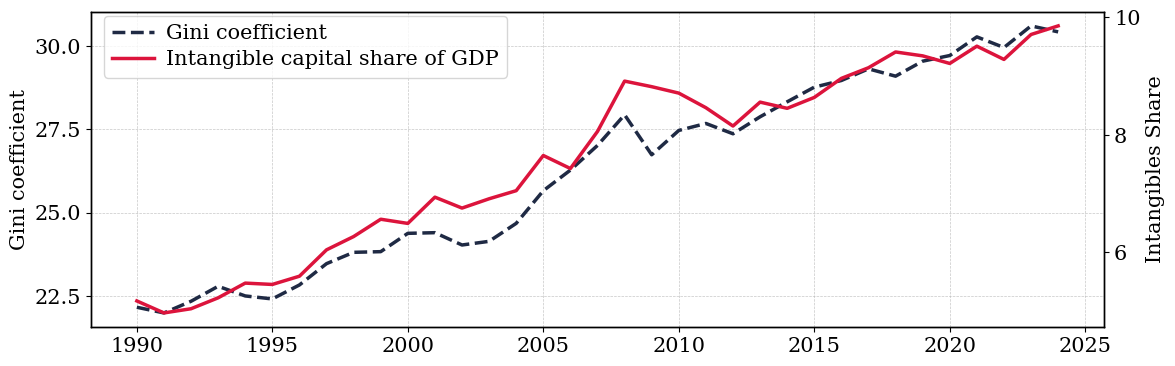

In [11]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
ax1_twin = ax1.twinx()

line1 = ax1.plot(gini.TID, gini.INDHOLD, 
                 label='Gini coefficient', linewidth=2.5, 
                 color='#1F2A44', ls='--')

line2 = ax1_twin.plot(
    investment_timeseries.index,
    investment_timeseries.intangible,
    label='Intangible capital share of GDP', linewidth=2.5, color='crimson')

# ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient")
ax1_twin.set_ylabel("Intangibles Share")
# ax1.set_title("Gini Coefficient vs Intangibles Share", pad=15)
ax1.grid(True, which="both", linestyle="--", alpha=0.7, linewidth=0.5)
ax1.locator_params(axis='y', nbins=4)
ax1_twin.locator_params(axis='y', nbins=4)

lines = line1 + line2
labels = [l.get_label() for l in lines]

fig.legend(lines, labels, loc='upper left', 
           ncol=1, frameon=True, bbox_to_anchor=(0.09, 0.95))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('0_output/corr_arg.png')
plt.show()